In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataframe = pd.read_csv(r"C:\Users\kapus\Downloads\swiggy.csv")

print(dataframe.head())

    ID         Area       City         Restaurant  Price  Avg ratings  \
0  211  Koramangala  Bangalore        Tandoor Hut  300.0          4.4   
1  221  Koramangala  Bangalore      Tunday Kababi  300.0          4.1   
2  246    Jogupalya  Bangalore            Kim Lee  650.0          4.4   
3  248  Indiranagar  Bangalore  New Punjabi Hotel  250.0          3.9   
4  249  Indiranagar  Bangalore                Nh8  350.0          4.0   

   Total ratings                                          Food type  \
0            100          Biryani,Chinese,North Indian,South Indian   
1            100                                   Mughlai,Lucknowi   
2            100                                            Chinese   
3            500               North Indian,Punjabi,Tandoor,Chinese   
4             50  Rajasthani,Gujarati,North Indian,Snacks,Desser...   

        Address  Delivery time  
0     5Th Block             59  
1     5Th Block             56  
2   Double Road             50  
3 

In [2]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   object 
 2   City           8680 non-null   object 
 3   Restaurant     8680 non-null   object 
 4   Price          8680 non-null   float64
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   object 
 8   Address        8680 non-null   object 
 9   Delivery time  8680 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 678.3+ KB


In [3]:
print(dataframe.columns)


Index(['ID', 'Area', 'City', 'Restaurant', 'Price', 'Avg ratings',
       'Total ratings', 'Food type', 'Address', 'Delivery time'],
      dtype='object')


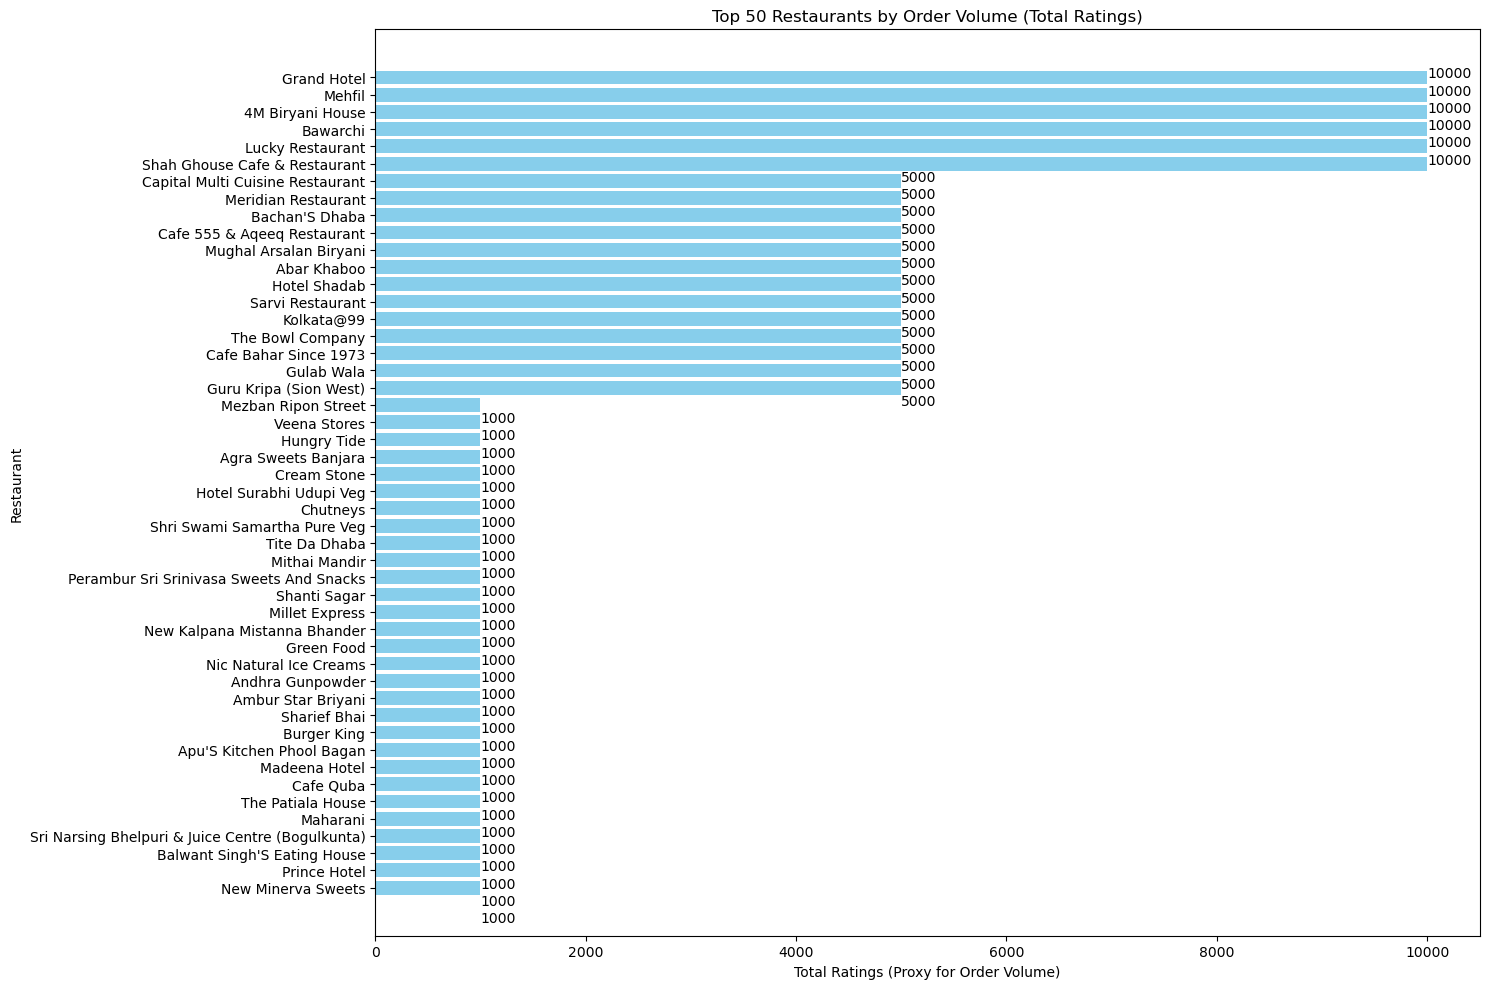

In [4]:

# Load the dataset
df = pd.read_csv(r"C:\Users\kapus\Downloads\swiggy.csv")

# Clean and prepare the data
df['Total ratings'] = pd.to_numeric(df['Total ratings'], errors='coerce')  # Convert to numeric
df = df.dropna(subset=['Total ratings'])  # Remove rows with missing values

# Get top 20 restaurants by total ratings (as a proxy for order volume)
top_restaurants = df.sort_values('Total ratings', ascending=False).head(50)

# Create the visualization
plt.figure(figsize=(15, 10))
plt.barh(top_restaurants['Restaurant'], top_restaurants['Total ratings'], color='skyblue')
plt.xlabel('Total Ratings (Proxy for Order Volume)')
plt.ylabel('Restaurant')
plt.title('Top 50 Restaurants by Order Volume (Total Ratings)')
plt.gca().invert_yaxis()  # Show highest at top
plt.tight_layout()

# Add value labels
for index, value in enumerate(top_restaurants['Total ratings']):
    plt.text(value, index, str(value))

plt.show()

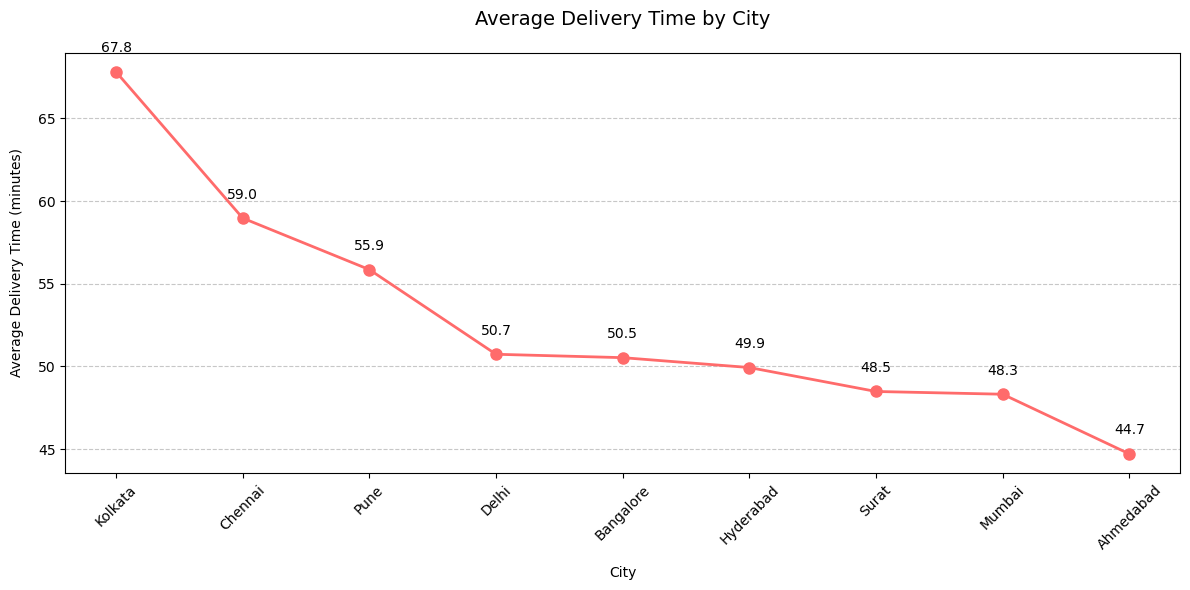

In [5]:

df['Delivery time'] = pd.to_numeric(df['Delivery time'], errors='coerce')
df = df.dropna(subset=['Delivery time'])
plt.figure(figsize=(12, 6))
delivery_by_city = df.groupby('City')['Delivery time'].mean().sort_values(ascending=False)
delivery_by_city.plot(
    kind='line',
    marker='o',
    color='#FF6B6B',
    linewidth=2,
    markersize=8
)
plt.title('Average Delivery Time by City', pad=20, fontsize=14)
plt.xlabel('City', labelpad=10)
plt.ylabel('Average Delivery Time (minutes)', labelpad=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for x, y in zip(range(len(delivery_by_city)), delivery_by_city):
    plt.text(x, y+1, f"{y:.1f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

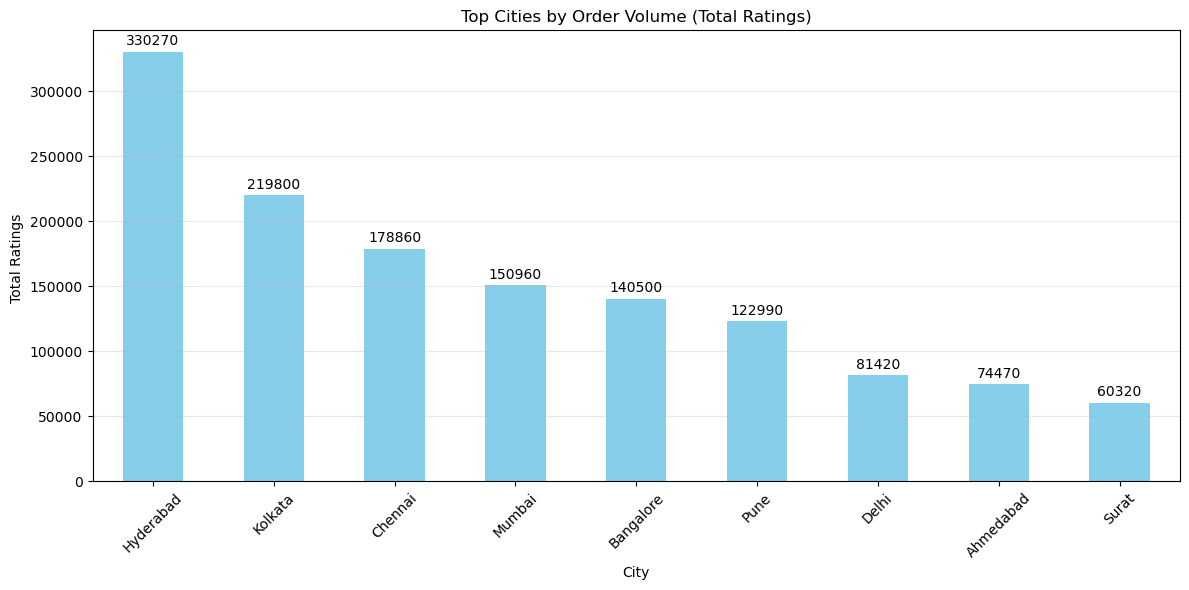

Top Cities by Order Volume:
City
Hyderabad    330270
Kolkata      219800
Chennai      178860
Mumbai       150960
Bangalore    140500
Pune         122990
Delhi         81420
Ahmedabad     74470
Surat         60320
Name: Total ratings, dtype: int64


In [13]:
df['Total ratings'] = pd.to_numeric(df['Total ratings'], errors='coerce')
df = df.dropna(subset=['Total ratings'])
city_orders = df.groupby('City')['Total ratings'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
city_orders.head(10).plot(kind='bar', color='skyblue')
plt.title('Top Cities by Order Volume (Total Ratings)')
plt.ylabel('Total Ratings ')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(city_orders.head(10)):
    plt.text(i, v+5000, str(int(v)), ha='center')

plt.tight_layout()
plt.show()
print("Top Cities by Order Volume:")
print(city_orders.head(10))

In [7]:



hyderabad_df = df[df['City'] == 'Hyderabad'].copy()

# Clean and prepare the data
hyderabad_df['Total ratings'] = pd.to_numeric(hyderabad_df['Total ratings'], errors='coerce')
hyderabad_df = hyderabad_df.dropna(subset=['Total ratings'])

# Group by Area and calculate order metrics
area_orders = hyderabad_df.groupby('Area').agg(
    Total_Orders=('Total ratings', 'sum'),
    Restaurant_Count=('Restaurant', 'count'),
    Avg_Rating=('Avg ratings', 'mean'),
    Avg_Delivery_Time=('Delivery time', 'mean')
).sort_values('Total_Orders', ascending=False)

# Format the output
area_orders['Total_Orders'] = area_orders['Total_Orders'].astype(int)
area_orders['Avg_Rating'] = area_orders['Avg_Rating'].round(2)
area_orders['Avg_Delivery_Time'] = area_orders['Avg_Delivery_Time'].round(1)

# Display top areas
print("Top Areas in Hyderabad by Order Volume:")
print(area_orders.head(20).to_markdown(tablefmt="grid"))

Top Areas in Hyderabad by Order Volume:
+-------------------------+----------------+--------------------+--------------+---------------------+
| Area                    |   Total_Orders |   Restaurant_Count |   Avg_Rating |   Avg_Delivery_Time |
+=========================+================+====================+==============+=====================+
| Banjara Hills           |          27170 |                113 |         3.69 |                61.7 |
+-------------------------+----------------+--------------------+--------------+---------------------+
| Koti                    |          18710 |                 23 |         4    |                32.2 |
+-------------------------+----------------+--------------------+--------------+---------------------+
| Narayanguda             |          17760 |                 19 |         3.81 |                29.8 |
+-------------------------+----------------+--------------------+--------------+---------------------+
| Toli Chowki             |      

In [8]:

# Filter for Bangalore only and clean data
bangalore_df = df[df['City'] == 'Bangalore'].copy()
bangalore_df['Total ratings'] = pd.to_numeric(bangalore_df['Total ratings'], errors='coerce')
bangalore_df = bangalore_df.dropna(subset=['Total ratings'])

# Get top restaurants by order volume (total ratings)
top_restaurants = bangalore_df.sort_values('Total ratings', ascending=False)[[
    'Restaurant', 
    'Area', 
    'Total ratings', 
    'Avg ratings', 
    'Price', 
    'Delivery time'
]].head(30)

# Format the output
top_restaurants['Avg ratings'] = top_restaurants['Avg ratings'].round(2)
top_restaurants['Delivery time'] = top_restaurants['Delivery time'].round(0).astype(int)

# Display results
print("Top 30 Restaurants in Bangalore by Order Volume:")
print(top_restaurants.to_markdown(tablefmt="grid", index=False))

Top 30 Restaurants in Bangalore by Order Volume:
+-----------------------------------+---------------------+-----------------+---------------+---------+-----------------+
| Restaurant                        | Area                |   Total ratings |   Avg ratings |   Price |   Delivery time |
+===================================+=====================+=================+===============+=========+=================+
| Savoury                           | Pulikeshi Nagar     |            1000 |           4.4 |     800 |              48 |
+-----------------------------------+---------------------+-----------------+---------------+---------+-----------------+
| Chai Days                         | Kodihalli           |            1000 |           4.4 |     200 |              53 |
+-----------------------------------+---------------------+-----------------+---------------+---------+-----------------+
| The Purple Pan                    | Rajajinagar         |            1000 |           4.1 |    

In [10]:



mumbai_df = df[df['City'] == 'Mumbai'].copy()

# Clean and prepare the data
mumbai_df['Total ratings'] = pd.to_numeric(mumbai_df['Total ratings'], errors='coerce')
mumbai_df = mumbai_df.dropna(subset=['Total ratings'])

# Group by Area and calculate order metrics
area_orders = mumbai_df.groupby('Area').agg(
    Total_Orders=('Total ratings', 'sum'),
    Restaurant_Count=('Restaurant', 'count'),
    Avg_Rating=('Avg ratings', 'mean'),
    Avg_Delivery_Time=('Delivery time', 'mean')
).sort_values('Total_Orders', ascending=False)

# Format the output
area_orders['Total_Orders'] = area_orders['Total_Orders'].astype(int)
area_orders['Avg_Rating'] = area_orders['Avg_Rating'].round(2)
area_orders['Avg_Delivery_Time'] = area_orders['Avg_Delivery_Time'].round(1)

# Display top areas
print("Top Areas in Mumbai by Order Volume:")
print(area_orders.head(20).to_markdown(tablefmt="grid"))

Top Areas in Mumbai by Order Volume:
+--------------------+----------------+--------------------+--------------+---------------------+
| Area               |   Total_Orders |   Restaurant_Count |   Avg_Rating |   Avg_Delivery_Time |
+====================+================+====================+==============+=====================+
| Chembur            |          30750 |                208 |         3.69 |                49.9 |
+--------------------+----------------+--------------------+--------------+---------------------+
| Santacruz East     |          15060 |                110 |         3.77 |                39.7 |
+--------------------+----------------+--------------------+--------------+---------------------+
| Andheri East       |          13820 |                135 |         3.74 |                54.7 |
+--------------------+----------------+--------------------+--------------+---------------------+
| Kurla              |          13260 |                129 |         3.41 |      